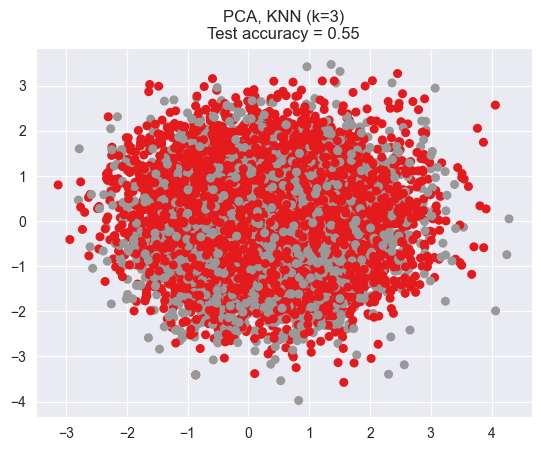

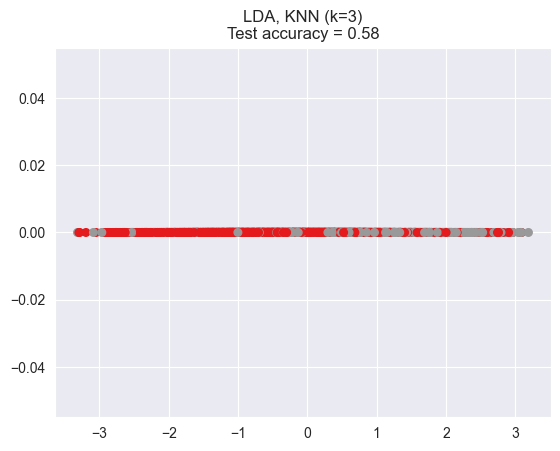

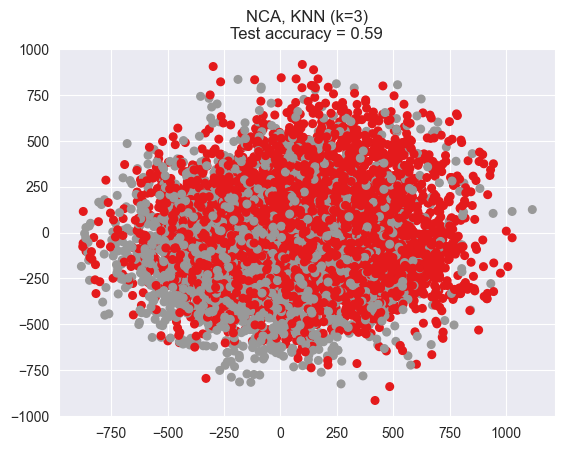

In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE  # Import SMOTE

n_neighbors = 3
random_state = 0

# Load the data (replace with the actual path of your dataset)
data = pd.read_csv('../data/domestic_violence_fake_data.csv')

# Split the data into features and target label 'Victim'
x = data[["Age", "Exchange_Sex", "Children", "Suicide_Attempt", "Jail", "Male", "LGBQ", "White", "Literal_Homeless", "Weapon", "Gang", "PTSD", "Depressed", "Community_Violence", "Sexual_Abuse", "Hard_Drug_Use", "Foster_Care", "Job"]]
y = data["Victim"]

# Split into train/test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.5, stratify=y, random_state=random_state
)

# Apply SMOTE to the training set to handle class imbalance
smote = SMOTE(random_state=random_state)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

# Get the number of features (dimensions)
dim = x.shape[1]

# Get the number of unique classes in the target
n_classes = len(np.unique(y))

# Reduce dimension to 2 with PCA
pca = make_pipeline(StandardScaler(), PCA(n_components=2, random_state=random_state))

# Dynamically determine the valid number of components for LDA
n_components_lda = min(x.shape[1], len(np.unique(y)) - 1)
lda = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(n_components=n_components_lda))

# Reduce dimension to 2 with NeighborhoodComponentAnalysis
nca = make_pipeline(
    StandardScaler(),
    NeighborhoodComponentsAnalysis(n_components=2, random_state=random_state),
)

# Use a nearest neighbor classifier to evaluate the methods
knn = KNeighborsClassifier(n_neighbors=n_neighbors)

# Make a list of the methods to be compared
dim_reduction_methods = [("PCA", pca), ("LDA", lda), ("NCA", nca)]

# Plot the results for each dimensionality reduction method
for i, (name, model) in enumerate(dim_reduction_methods):
    plt.figure()

    # Fit the method's model
    model.fit(x_train_smote, y_train_smote)

    # Fit a nearest neighbor classifier on the embedded training set
    knn.fit(model.transform(x_train_smote), y_train_smote)

    # Compute the nearest neighbor accuracy on the embedded test set
    acc_knn = knn.score(model.transform(x_test), y_test)

    # Embed the data set in 2 dimensions using the fitted model
    X_embedded = model.transform(x)

    # Check the number of dimensions in the transformed data
    if X_embedded.shape[1] == 1:
        # If 1D, plot the data along a single axis
        plt.scatter(X_embedded[:, 0], np.zeros_like(X_embedded[:, 0]), c=y, s=30, cmap="Set1")
        plt.title(
            "{}, KNN (k={})\nTest accuracy = {:.2f}".format(name, n_neighbors, acc_knn)
        )
    else:
        # If 2D, plot the data in 2D
        plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, s=30, cmap="Set1")
        plt.title(
            "{}, KNN (k={})\nTest accuracy = {:.2f}".format(name, n_neighbors, acc_knn)
        )

# Show all plots
plt.show()
